

# **Dependencies**



In [76]:
!pip install -q monai nibabel
!pip install nibabel -q
!pip install scikit-learn -q
!pip install tqdm -q
!pip install split-folders -q
!pip install torchinfo -q
!pip install segmentation-models-pytorch-3d -q
!pip install livelossplot -q
!pip install torchmetrics -q
!pip install tensorboard -q

In [77]:
# system
import os
import glob
import random
import gc
import time

# numerical
import numpy as np

# visualization
import matplotlib.pyplot as plt

# medical imaging
import nibabel as nib

# deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F


# MONAI
from monai.data import Dataset, DataLoader
from monai.losses import DiceCELoss

from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    NormalizeIntensityd,
    CropForegroundd,
    RandCropByPosNegLabeld,
    RandFlipd,
    RandRotate90d,
    RandShiftIntensityd,
    ToTensord
)

# training utilities
from tqdm import tqdm
from torchmetrics import MeanMetric

# **Mount Google Drive**
***This applies only for google drive,***
***please change the code below to adapt the rest.***

In [78]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [79]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'data',
 'Untitled',
 'SFU_CV_lab2',
 'dokumen.pub_ethics-for-the-information-age-9nbsped-9780138238537-0138238758-9780138238759.pdf',
 'The Social Network: Idea Ownership vs. Execution.gslides',
 'Untitled document.gdoc',
 'mridata']

# **Create MONAI Dataset Presetting**
***change to correct folder for the following directories.***

In [80]:
data_dir = "/content/drive/MyDrive/mridata"
train_dir = data_dir + "/training"
val_dir = data_dir + "/validation"

In [81]:
def create_dataset_dict(data_path, include_label=True):

    patients = sorted(os.listdir(data_path))
    data = []

    for p in patients:

        p_path = os.path.join(data_path, p)

        t1n = glob.glob(os.path.join(p_path, "*t1n.nii.gz"))[0]
        t1c = glob.glob(os.path.join(p_path, "*t1c.nii.gz"))[0]
        t2f = glob.glob(os.path.join(p_path, "*t2f.nii.gz"))[0]
        t2w = glob.glob(os.path.join(p_path, "*t2w.nii.gz"))[0]

        item = {
            "image": [t1n, t1c, t2f, t2w]
        }

        # Only include label if the file exists (training set)
        if include_label:
            seg_files = glob.glob(os.path.join(p_path, "*seg.nii.gz"))
            if seg_files:
                item["label"] = seg_files[0]

        data.append(item)

    return data


train_files = create_dataset_dict(train_dir, include_label=True)
val_files = create_dataset_dict(val_dir, include_label=False)
print("Training cases:", len(train_files))
print("Validation cases:", len(val_files))

Training cases: 10
Validation cases: 5


# **MONAI Transform**

In [82]:
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    NormalizeIntensityd(keys="image", nonzero=True),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(96, 96, 96),
        pos=1,
        neg=1,
        num_samples=4,
        image_key="image",
        image_threshold=0,
    ),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandRotate90d(keys=["image", "label"], prob=0.5, spatial_axes=[0, 2]),
    RandShiftIntensityd(keys="image", offsets=0.1, prob=0.5),
    ToTensord(keys=["image", "label"])
])

val_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    CropForegroundd(keys=["image"], source_key="image"),
    NormalizeIntensityd(keys="image", nonzero=True),
    ToTensord(keys=["image"])
])

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


# **Creating dataset**

In [83]:
train_ds = Dataset(train_files, transform=train_transforms)
val_ds = Dataset(val_files, transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=1)

# **Check if files are in dataset**

In [84]:
# Since num_samples > 1 in transforms, ds[0] returns a list of crops
samples = train_ds[0]
sample = samples[0]

print(f"Type of samples: {type(samples)}")
print(f"Number of crops per image: {len(samples)}")
print(f"Keys in a single crop: {sample.keys()}")

print("Image shape:", sample["image"].shape)
print("Label shape:", sample["label"].shape)

Type of samples: <class 'list'>
Number of crops per image: 4
Keys in a single crop: dict_keys(['image', 'label', 'foreground_start_coord', 'foreground_end_coord'])
Image shape: torch.Size([4, 96, 96, 96])
Label shape: torch.Size([1, 96, 96, 96])


# **Show Example Images From dataset**

***Training visualization***

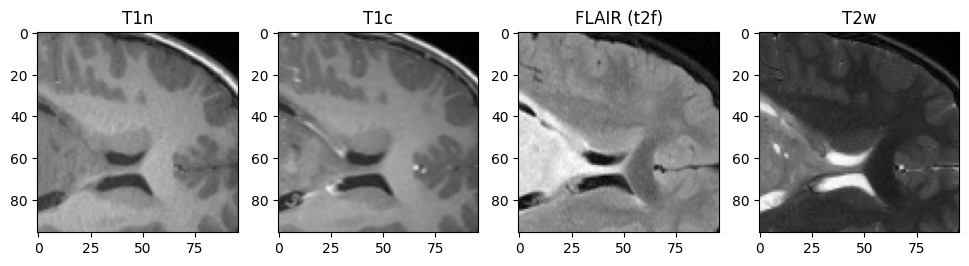

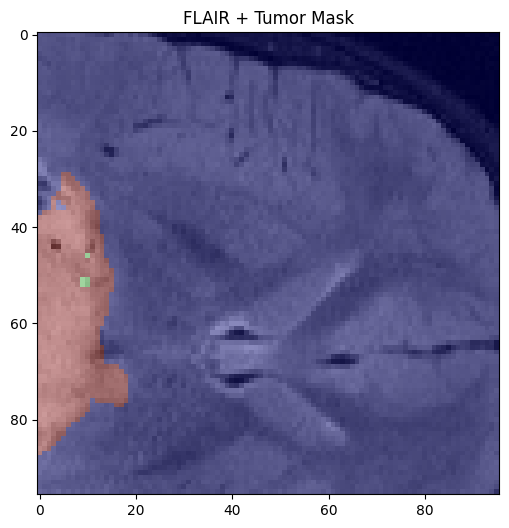

In [85]:
train_sample = next(iter(train_loader))

image = train_sample["image"][0]
label = train_sample["label"][0]

slice_idx = image.shape[-1] // 2

plt.figure(figsize=(15,4))

plt.subplot(1,5,1)
plt.title("T1n")
plt.imshow(image[0,:,:,slice_idx], cmap="gray")

plt.subplot(1,5,2)
plt.title("T1c")
plt.imshow(image[1,:,:,slice_idx], cmap="gray")

plt.subplot(1,5,3)
plt.title("FLAIR (t2f)")
plt.imshow(image[2,:,:,slice_idx], cmap="gray")

plt.subplot(1,5,4)
plt.title("T2w")
plt.imshow(image[3,:,:,slice_idx], cmap="gray")
plt.show()


# find slices with tumor
tumor_slices = (label[0] > 0).sum(dim=(0,1)).nonzero().squeeze()

slice_idx = tumor_slices[len(tumor_slices)//2].item()

plt.figure(figsize=(6,6))

plt.imshow(image[2,:,:,slice_idx], cmap="gray")
plt.imshow(label[0,:,:,slice_idx], cmap="jet", alpha=0.4)

plt.title("FLAIR + Tumor Mask")
plt.show()


# **Validation visualization**

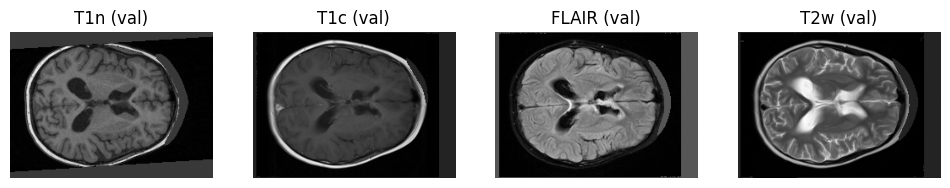

In [86]:
val_sample = next(iter(val_loader))

image = val_sample["image"][0]

slice_idx = image.shape[-1] // 2

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.title("T1n (val)")
plt.imshow(image[0,:,:,slice_idx], cmap="gray")
plt.axis("off")

plt.subplot(1,4,2)
plt.title("T1c (val)")
plt.imshow(image[1,:,:,slice_idx], cmap="gray")
plt.axis("off")

plt.subplot(1,4,3)
plt.title("FLAIR (val)")
plt.imshow(image[2,:,:,slice_idx], cmap="gray")
plt.axis("off")

plt.subplot(1,4,4)
plt.title("T2w (val)")
plt.imshow(image[3,:,:,slice_idx], cmap="gray")
plt.axis("off")

plt.show()

# ***Code for Unet starts here***

# **3D U-Net model**

***Double convolution block***

In [87]:
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv3d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

***Down block***

In [88]:
class Down(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.pool = nn.MaxPool3d(2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x):

        x = self.pool(x)
        x = self.conv(x)

        return x

***Up block***

In [89]:
class Up(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose3d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):

        x1 = self.up(x1)

        # compute size difference
        diffZ = x2.size()[2] - x1.size()[2]
        diffY = x2.size()[3] - x1.size()[3]
        diffX = x2.size()[4] - x1.size()[4]

        # pad x1 to match x2
        x1 = F.pad(
            x1,
            [
                diffX // 2, diffX - diffX // 2,
                diffY // 2, diffY - diffY // 2,
                diffZ // 2, diffZ - diffZ // 2
            ]
        )

        x = torch.cat([x2, x1], dim=1)

        return self.conv(x)

# ***Full 3D U-Net***
**Change size of layers if RAM is full**

In [90]:
class UNet3D(nn.Module):
    def __init__(self, in_channels=4, out_channels=1):
        super().__init__()

        self.inc = DoubleConv(in_channels, 32)
        self.down1 = Down(32, 64)
        self.down2 = Down(64, 128)
        self.down3 = Down(128, 256)

        # Added Dropout to reduce overfitting
        self.dropout = nn.Dropout3d(p=0.2)

        self.up1 = Up(256, 128)
        self.up2 = Up(128, 64)
        self.up3 = Up(64, 32)

        self.outc = nn.Conv3d(32, out_channels, 1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.dropout(self.down3(x3))

        x = self.up1(x4, x3)
        x = self.up2(x, x2)
        x = self.up3(x, x1)

        return self.outc(x)

# ***Define running device***

In [91]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


***Model***

In [92]:
model = UNet3D(
    in_channels=4,   # t1n, t1c, t2f, t2w
    out_channels=1
).to(device)

# **Loss function and Optimizer**
***Used Dice loss***
***and adam optimizer. Can be changed in the future.***
***Added scalar to reduce RAM***

In [93]:
# Using DiceCELoss which combines Dice loss (good for overlap) and Cross Entropy (good for pixel-wise accuracy)
# We use sigmoid=True because we have a single output channel (binary segmentation)
criterion = DiceCELoss(
    sigmoid=True,
    squared_pred=True,
    smooth_nr=1e-5,
    smooth_dr=1e-5
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scaler = torch.amp.GradScaler('cuda')

print("Loss: DiceCELoss with Sigmoid (optimized for binary segmentation)")
print("Optimizer: Adam (LR=1e-4)")

Loss: DiceCELoss with Sigmoid (optimized for binary segmentation)
Optimizer: Adam (LR=1e-4)


# **Training loop**

In [94]:
from monai.metrics import DiceMetric
from monai.transforms import Activations, AsDiscrete

dice_metric = DiceMetric(include_background=False, reduction="mean")
post_trans = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])

def train_epoch():
    model.train()
    total_loss = 0
    dice_metric.reset()

    for batch in train_loader:
        images = batch["image"].to(device)
        target = batch["label"].to(device)

        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, target)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        # Calculate training dice for feedback
        train_outputs = [post_trans(i) for i in outputs]
        dice_metric(y_pred=train_outputs, y=target)

    return total_loss / len(train_loader), dice_metric.aggregate().item()

# **Validation**

In [95]:
@torch.no_grad()
def validate_epoch():
    model.eval()
    for batch in val_loader:
        images = batch["image"].to(device)
        with torch.amp.autocast("cuda"):
            _ = model(images)
    return 0.0

# **Running training**
***change epochs for better results.***
***Due to limited space on RAM, epoch is set to 1***

In [96]:
num_epochs = 10

for epoch in range(num_epochs):
    train_loss, train_dice = train_epoch()
    _ = validate_epoch() # Runs inference on val set

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Dice: {train_dice:.4f}"
    )


Epoch 1/10 | Train Loss: 1.3645 | Train Dice: 0.0621
Epoch 2/10 | Train Loss: 1.1548 | Train Dice: 0.0982
Epoch 3/10 | Train Loss: 1.0493 | Train Dice: 0.1630
Epoch 4/10 | Train Loss: 1.0108 | Train Dice: 0.1805
Epoch 5/10 | Train Loss: 0.9398 | Train Dice: 0.1969
Epoch 6/10 | Train Loss: 0.9056 | Train Dice: 0.2217
Epoch 7/10 | Train Loss: 0.8618 | Train Dice: 0.2813
Epoch 8/10 | Train Loss: 0.8828 | Train Dice: 0.1949
Epoch 9/10 | Train Loss: 0.8419 | Train Dice: 0.2254
Epoch 10/10 | Train Loss: 0.8288 | Train Dice: 0.2651


# **Model evaluation**

In [105]:
model.eval()
# Evaluate on a training sample to see accuracy
test_sample = next(iter(train_loader))
image_test = test_sample["image"].to(device)
label_test = test_sample["label"].to(device)

with torch.no_grad():
    with torch.amp.autocast("cuda"):
        pred_test = model(image_test)
        # Calculate Dice for this specific sample
        test_outputs = [post_trans(i) for i in pred_test]
        dice_metric.reset()
        dice_metric(y_pred=test_outputs, y=label_test)
        sample_dice = dice_metric.aggregate().item()

print(f"Sample Accuracy (Dice Score): {sample_dice:.4f}")

# Now get a real validation sample for visualization
val_sample = next(iter(val_loader))
val_image = val_sample["image"].to(device)
with torch.no_grad():
    with torch.amp.autocast("cuda"):
        val_pred = model(val_image)

Sample Accuracy (Dice Score): 0.0531


# **Extract learned segment**

In [106]:
# For out_channels=1, we use sigmoid + thresholding
# Extracting from the validation prediction
pred_prob = torch.sigmoid(val_pred).cpu()[0, 0].numpy()
pred_mask = (pred_prob > 0.5).astype(np.float32)

image_cpu = val_image.cpu()[0]
# Select a slice from the middle of the volume
slice_idx = image_cpu.shape[-1] // 2

# **Visualize MRI and prediction**

In [101]:
print("pred classes:", np.unique(pred_mask))
print("max prob:", pred_prob.max())
print("min prob:", pred_prob.min())
print("mean prob:", pred_prob.mean())

pred classes: [0. 1.]
max prob: 0.997
min prob: 0.1494
mean prob: 0.2642


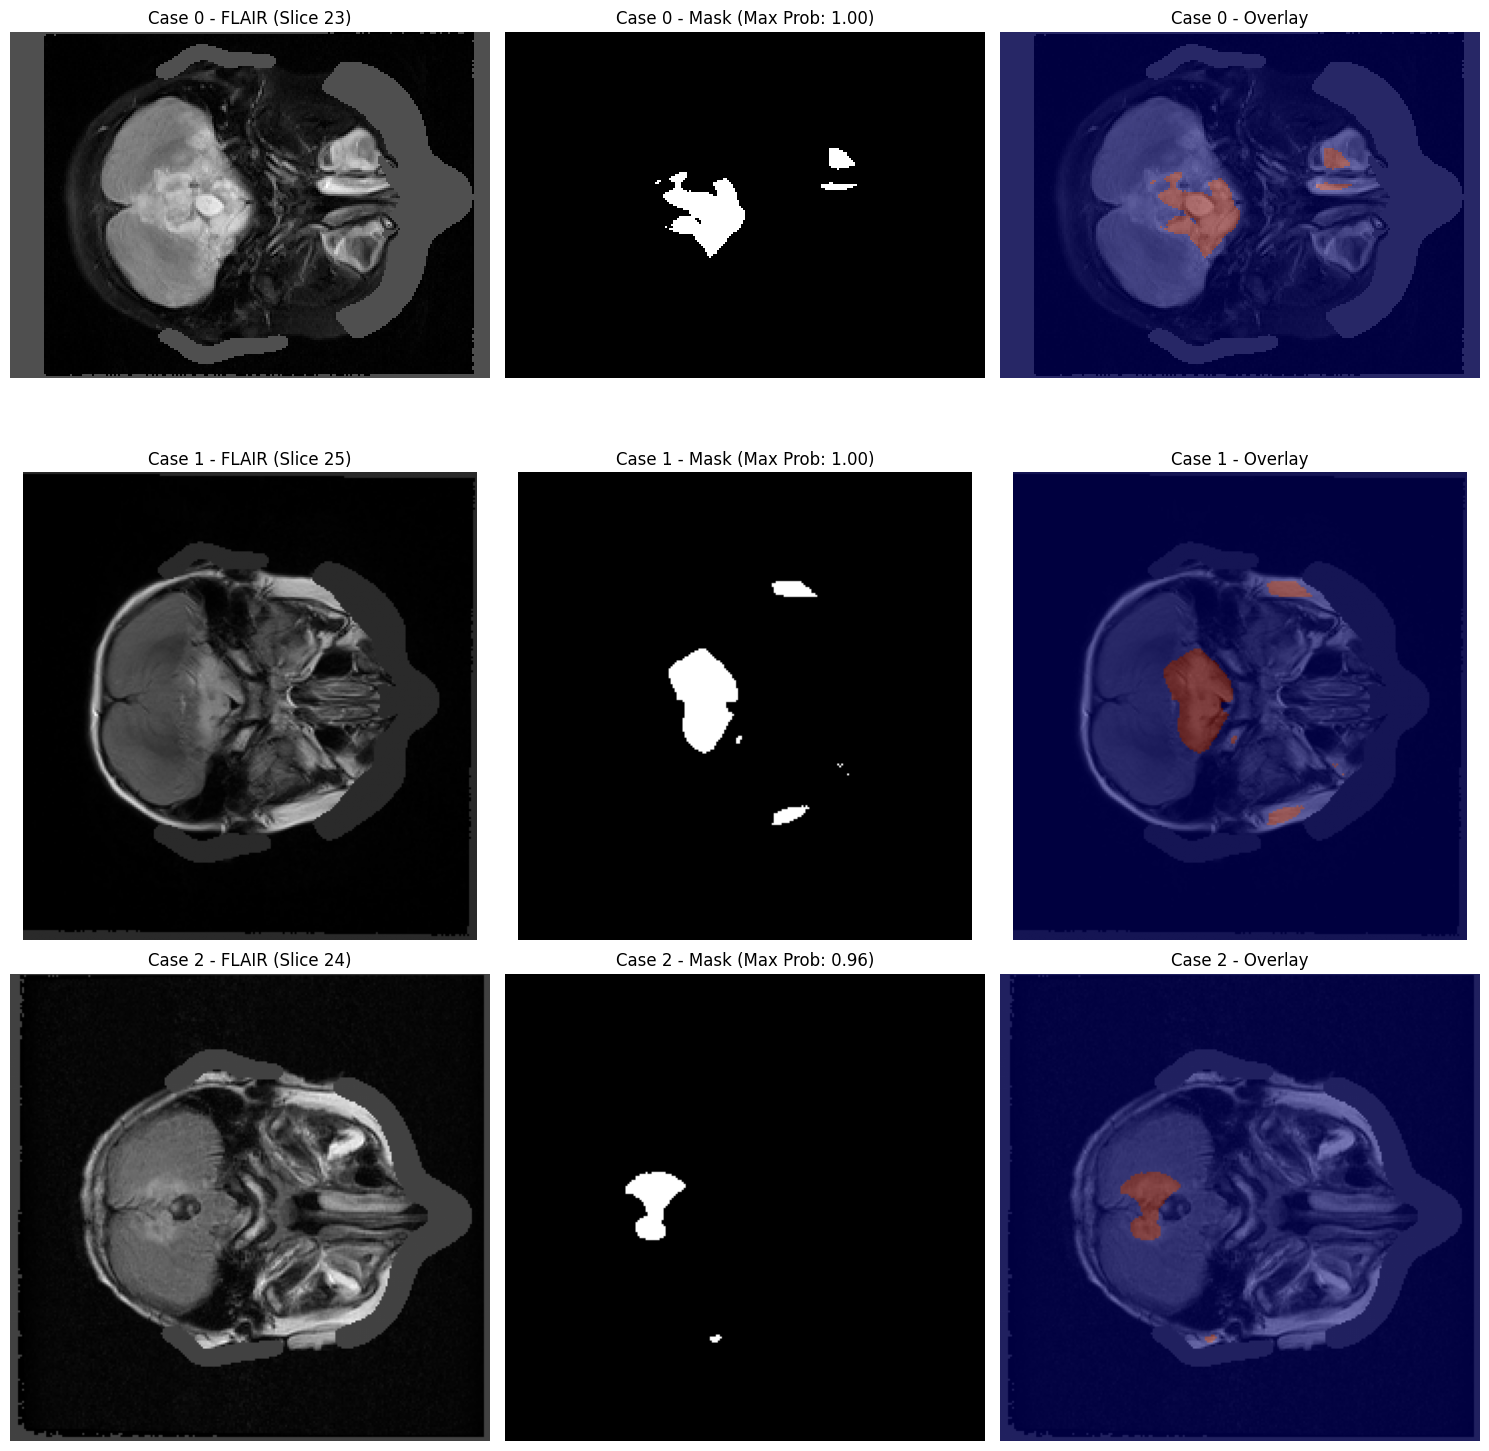

In [108]:
model.eval()
num_to_show = 3
plt.figure(figsize=(15, 5 * num_to_show))

with torch.no_grad():
    for i, batch in enumerate(val_loader):
        if i >= num_to_show: break

        val_image = batch["image"].to(device)
        with torch.amp.autocast("cuda"):
            val_pred = model(val_image)

        # Process prediction
        pred_prob = torch.sigmoid(val_pred).cpu()[0, 0].numpy()
        pred_mask = (pred_prob > 0.5).astype(np.float32)
        image_cpu = val_image.cpu()[0]

        # Find slice with highest probability to ensure we see the model's 'best guess'
        slice_idx = np.argmax(np.max(pred_prob, axis=(0, 1)))
        max_val = np.max(pred_prob)

        plt.subplot(num_to_show, 3, i*3 + 1)
        plt.title(f"Case {i} - FLAIR (Slice {slice_idx})")
        plt.imshow(image_cpu[2, :, :, slice_idx], cmap='gray')
        plt.axis('off')

        plt.subplot(num_to_show, 3, i*3 + 2)
        plt.title(f"Case {i} - Mask (Max Prob: {max_val:.2f})")
        plt.imshow(pred_mask[:, :, slice_idx], cmap='gray')
        plt.axis('off')

        plt.subplot(num_to_show, 3, i*3 + 3)
        plt.title(f"Case {i} - Overlay")
        plt.imshow(image_cpu[2, :, :, slice_idx], cmap='gray')
        if np.any(pred_mask[:, :, slice_idx] > 0):
            plt.imshow(pred_mask[:, :, slice_idx], cmap='jet', alpha=0.5)
        plt.axis('off')

plt.tight_layout()
plt.show()

# **Save predictions**

In [109]:
import nibabel as nib
import numpy as np

# Save the probability map (raw confidence) instead of just the 0/1 mask
# We cast to float32 to avoid the HeaderDataError with float16
prob_volume = torch.sigmoid(val_pred).cpu().numpy()[0, 0].astype(np.float32)
nii = nib.Nifti1Image(prob_volume, np.eye(4))
nib.save(nii, "prediction_probability.nii.gz")

print("Saved prediction_probability.nii.gz successfully in float32 format.")

Saved prediction_probability.nii.gz successfully in float32 format.
